In [ ]:
LANGUAGE = "russian"
RESOURCE = "high"

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import pandas as pd
import pickle
import os
import pickle
import re
import argparse
import time
import logging
from pprint import pformat

import numpy as np
logging.basicConfig(level=logging.DEBUG)

In [ ]:
from sklearn import metrics
def aa_metrics(labels, predictions, raw_outputs, prefix='', no_auc=False, special=False):

    accuracy = metrics.accuracy_score(labels, predictions)
    macro_accuracy = metrics.balanced_accuracy_score(labels, predictions)
    results = {
        f'{prefix}accuracy': accuracy,
        f'{prefix}macro_accuracy': macro_accuracy,
    }
    if special:
        return results

    micro_recall = metrics.recall_score(labels, predictions, average='micro')
    macro_recall = metrics.recall_score(labels, predictions, average='macro')
    micro_precision = metrics.precision_score(labels, predictions, average='micro')
    macro_precision = metrics.precision_score(labels, predictions, average='macro')
    micro_f1 = metrics.f1_score(labels, predictions, average="micro")
    macro_f1 = metrics.f1_score(labels, predictions, average="macro")

    results.update({
        f'{prefix}micro_recall': micro_recall,
        f'{prefix}macro_recall': macro_recall,
        f'{prefix}micro_precision': micro_precision,
        f'{prefix}macro_precision': macro_precision,
        f'{prefix}micro_f1': micro_f1,
        f'{prefix}macro_f1': macro_f1,
    })

    if not no_auc:
        ovr_weighted_auc = metrics.roc_auc_score(labels, raw_outputs, average='weighted', multi_class='ovr')
        ovr_macro_auc = metrics.roc_auc_score(labels, raw_outputs, average='macro', multi_class='ovr')
        ovo_weighted_auc = metrics.roc_auc_score(labels, raw_outputs, average='weighted', multi_class='ovo')
        ovo_macro_auc = metrics.roc_auc_score(labels, raw_outputs, average='macro', multi_class='ovo')



        results.update({
            f'{prefix}ovr_weighted_auc': ovr_weighted_auc,
            f'{prefix}ovr_macro_auc': ovr_macro_auc,
            f'{prefix}ovo_weighted_auc': ovo_weighted_auc,
            f'{prefix}ovo_macro_auc': ovo_macro_auc,
        })

    logging.info(results)
    return results

In [4]:
train_data = pd.read_csv(f"../data/dataset-{RESOURCE}-res/train-{LANGUAGE}-llm-dataset.csv")
authors = sorted(list(set(train_data['author'])))
author_id_map = {author: idx for idx, author in enumerate(authors)}
author_id_map

{'deepseek-v3.2': 0,
 'gemini-2.5-flash': 1,
 'gemini-2.5-pro': 2,
 'gpt-oss': 3,
 'qwen3-235b-a22b-2507': 4}

In [5]:
num_labels = len(author_id_map)
print("num of lavels:", num_labels)

num of lavels: 5


In [ ]:
from transformers import AutoTokenizer
metric = "norm_mean"
alpha = 1.5
grid = 50
method = "entropy"
model = "google/gemma-3-1b-it" ##TODO  
context_size = 1024
tokenizer = AutoTokenizer.from_pretrained(model)
vocab_size = tokenizer.vocab_size
max_value = np.log2(vocab_size)

/Users/matteog/WorkingOn/Thesis/multilingual-OOD-AA/trace_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
DEBUG:httpcore.connection:connect_tcp.started host='huggingface.co' port=443 local_address=None timeout=10 socket_options=None
DEBUG:httpcore.connection:connect_tcp.complete return_value=<httpcore._backends.sync.SyncStream object at 0x16966a6d0>
DEBUG:httpcore.connection:start_tls.started ssl_context=<ssl.SSLContext object at 0x1696c6f00> server_hostname='huggingface.co' timeout=10
DEBUG:httpcore.connection:start_tls.complete return_value=<httpcore._backends.sync.SyncStream object at 0x168efeed0>
DEBUG:httpcore.http11:send_request_headers.started request=<Request [b'HEAD']>
DEBUG:httpcore.http11:send_request_headers.complete
DEBUG:httpcore.http11:send_request_body.started request=<Request [b'HEA

In [7]:
model = "google-gemma-3-1b-it"

In [8]:
from scipy.stats import gaussian_kde
import torch
import wandb
from datasets import tqdm
from scipy.spatial.distance import jensenshannon
from sklearn import metrics
from sklearn.metrics.pairwise import cosine_similarity


def create_signature(data, grid_size, max_value):
    kde = gaussian_kde(data)

    x_grid = np.linspace(0, max_value, grid_size)
    y_grid = np.linspace(0, max_value, grid_size)
    X, Y = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    Z = kde(positions).reshape(X.shape)
    return X, Y, Z


def get_fingerprint(values, grid_size, max_value):
    pairs = [(values[i - 1], values[i]) for i in range(1, len(values))]
    pair_x = [pair[0] for pair in pairs]
    pair_y = [pair[1] for pair in pairs]
    data = np.vstack([pair_x, pair_y])
    X, Y, Z = create_signature(data, grid_size, max_value)
    return Z


def get_ref_fingerprint(method, author, data, grid, max_value):
    author_data = data[data['author'] == author]
    print("Author: {}; {}".format(author, len(author_data)))
    fingerprints = []
    
    for _, row in author_data.iterrows():
        curr_novel = row['novel_name']
        entropies = np.load(
            #f"../data/{method}/{model}-context-{context_size}-llm-novel-{curr_novel}.txt-{method}.npz")[
            f"../data/TRACE-scores/{LANGUAGE}/{method}/{model}-context-{context_size}-llm-novel-{curr_novel}.txt-{method}.npz")[
            method]
        pairs = [(entropies[i - 1], entropies[i]) for i in range(1, len(entropies))]
        pair_x = [pair[0] for pair in pairs]
        pair_y = [pair[1] for pair in pairs]
        data = np.vstack([pair_x, pair_y])
        X, Y, Z = create_signature(data, grid, max_value)
        fingerprints.append(Z)
    return fingerprints


def compute_normals(Z, dx, dy):
    # Compute gradients using central differences
    Zx = (np.roll(Z, -1, axis=1) - np.roll(Z, 1, axis=1)) / (2 * dx)
    Zy = (np.roll(Z, -1, axis=0) - np.roll(Z, 1, axis=0)) / (2 * dy)
    # Normal vector: (-Zx, -Zy, 1)
    normals = np.stack([-Zx, -Zy, np.ones_like(Z)], axis=-1)
    # Normalize
    norm = np.sqrt(normals[..., 0]**2 + normals[..., 1]**2 + normals[..., 2]**2)
    normals = normals / norm[..., np.newaxis]
    return normals


def get_mean_normal_angle(Z1, Z2, grid_size, max_value):
    x = np.linspace(0, max_value, grid_size)
    y = np.linspace(0, max_value, grid_size)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    # Compute normals
    normals1 = compute_normals(Z1, dx, dy)
    normals2 = compute_normals(Z2, dx, dy)

    # Compute angle between normals (in degrees)
    dot_product = np.sum(normals1 * normals2, axis=-1)
    dot_product = np.clip(dot_product, -1, 1)  # Avoid numerical errors
    angle_diff = np.arccos(dot_product) * 180 / np.pi

    # Normal comparison metrics
    mean_angle = np.mean(angle_diff)
    rms_angle = np.sqrt(np.mean(angle_diff ** 2))
    max_angle = np.max(angle_diff)
    return mean_angle * 100


def get_score(metric, fingerprint1, fingerprint2, grid, max_value):
    if metric == 'cos_sim':
        return cosine_similarity([fingerprint1.flatten()], [fingerprint2.flatten()])[0, 0]
    elif metric == 'frob_norm':
        return -1 * np.linalg.norm(fingerprint1 - fingerprint2, ord=2)
    elif metric == 'wass_dist':
        raise NotImplementedError
    elif metric == 'js_dist':
        return 1 - jensenshannon(fingerprint1.flatten(), fingerprint2.flatten())
    elif metric == "ssim":
        raise NotImplementedError
    elif metric == 'norm_mean':
        Z1 = fingerprint1
        Z2 = fingerprint2
        return -1 * get_mean_normal_angle(Z1, Z2, grid, max_value)

def get_predicted_author(entropies, author_ref_fingerprints_map, metric, grid, max_value):
    curr_fingerprint = get_fingerprint(entropies, grid, max_value)
    scores = []
    for author, author_fingerprints in author_ref_fingerprints_map.items():
        scores.append(np.max([get_score(metric, author_fingerprint, curr_fingerprint, grid, max_value) for author_fingerprint in author_fingerprints]))
    return np.argmax(scores), np.array(scores)


DEBUG:datasets:PyTorch version 2.10.0 available.


In [9]:
AUTHORS = sorted(list(set(train_data["author"])))
print("AUTHORS: ", len(AUTHORS))

AUTHORS:  5


In [10]:
author_ref_fingerprints_map = {}
for author in AUTHORS:
    author_ref_fingerprints_map[author] = get_ref_fingerprint(method, author, train_data, grid, max_value)
        
def get_entropy_predictions(test_data):
    y_pred = []
    y_scores = []
    for idx, row in tqdm(test_data.iterrows(), total=len(test_data)):
        curr_novel = row['novel_name']
        entropies = np.load(
            #f"../data/{method}/{model}-context-{context_size}-llm-novel-{curr_novel}.txt-{method}.npz")[method]
            f"../data/TRACE-scores/devset/{LANGUAGE}/{method}/{model}-context-{context_size}-llm-novel-{curr_novel}.txt-{method}.npz")[method]
        pred_author, score = get_predicted_author(entropies, author_ref_fingerprints_map, metric, grid, max_value)
        y_pred.append(pred_author)
        y_scores.append(score)
    return np.array(y_pred), np.array(y_scores)

Author: deepseek-v3.2; 18
Author: gemini-2.5-flash; 15
Author: gemini-2.5-pro; 16
Author: gpt-oss; 15
Author: qwen3-235b-a22b-2507; 15


In [ ]:
dev_data = pd.read_csv(f"../data/dataset-{RESOURCE}-res/devset-{LANGUAGE}.csv")
dev_texts = list(dev_data['text'])
dev_labels = np.array([author_id_map[author] for author in list(dev_data['author'])])
assert len(dev_texts) == len(dev_labels) == 10

In [12]:
train_texts = list(train_data['text'])
train_labels = np.array([author_id_map[author] for author in list(train_data['author'])])

In [14]:
dev_predictions, dev_probas = get_entropy_predictions(dev_data)

100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


In [16]:
aa_metrics(dev_labels, dev_predictions, dev_probas, prefix="", no_auc=True)

INFO:root:{'accuracy': 0.8, 'macro_accuracy': 0.8, 'micro_recall': 0.8, 'macro_recall': 0.8, 'micro_precision': 0.8, 'macro_precision': 0.9, 'micro_f1': 0.8, 'macro_f1': 0.7999999999999999}


{'accuracy': 0.8,
 'macro_accuracy': 0.8,
 'micro_recall': 0.8,
 'macro_recall': 0.8,
 'micro_precision': 0.8,
 'macro_precision': 0.9,
 'micro_f1': 0.8,
 'macro_f1': 0.7999999999999999}

In [17]:
def get_metric_for_threshold(y_true, y_pred_probs):
    n_classes = y_pred_probs.shape[1]
    assert n_classes == len(author_id_map)
    
    # Get top-1 predictions and their probabilities
    top1_probs = np.max(y_pred_probs, axis=1)
    top1_classes = np.argmax(y_pred_probs, axis=1)
    
    thresholds = np.linspace(-5, 0, 1001)
    results = []
    
    for threshold in thresholds:
        # Predictions: accept if prob > threshold, else reject as "unseen"
        accepted_mask = top1_probs >= threshold
        
        if np.sum(accepted_mask) == 0:
            primary_accuracy = 0
            primary_precision = 0
            primary_recall = 0
            primary_f1 = 0
        else:
            # Compute per-class metrics, then average
            class_accuracies = []
            class_precisions = []
            class_recalls = []
            class_f1s = []
            
            for class_id in range(n_classes):
                # Samples belonging to this class
                class_mask = (y_true == class_id)
                
                if np.sum(class_mask) == 0:
                    # print(threshold, class_id, "empty")
                    continue  # Skip classes with no samples
                
                # Among samples of this class, which were accepted?
                class_predicted_correct = (top1_classes == class_id) & class_mask & accepted_mask
                
                # Class recall: accepted and correct / total in class
                class_recall = np.sum(class_predicted_correct) / np.sum(class_mask)
                
                # Class precision: among all predictions for this class (accepted), how many correct?
                predicted_as_class = (top1_classes == class_id) & accepted_mask
                if np.sum(predicted_as_class) > 0:
                    class_precision = np.sum(class_predicted_correct) / np.sum(predicted_as_class)
                else:
                    class_precision = 0
                
                # Class accuracy: correct predictions / total in class
                class_accuracy = np.sum(class_predicted_correct) / np.sum(class_mask)
                
                # Class F1
                if class_precision + class_recall > 0:
                    class_f1 = 2 * (class_precision * class_recall) / (class_precision + class_recall)
                else:
                    class_f1 = 0
                
                class_accuracies.append(class_accuracy)
                class_precisions.append(class_precision)
                class_recalls.append(class_recall)
                class_f1s.append(class_f1)
            
            # print(class_precision, class_recall, class_f1, class_accuracies)
            # Macro average (unweighted mean across classes)
            macro_accuracy = np.mean(class_accuracies) if class_accuracies else 0
            macro_precision = np.mean(class_precisions) if class_precisions else 0
            macro_recall = np.mean(class_recalls) if class_recalls else 0
            macro_f1 = np.mean(class_f1s) if class_f1s else 0
            
            primary_accuracy = macro_accuracy
            primary_precision = macro_precision
            primary_recall = macro_recall
            primary_f1 = macro_f1
                
        
        coverage = np.mean(accepted_mask)  # Fraction of samples accepted
        
        results.append({
            'threshold': threshold,
            'accuracy': primary_accuracy,
            'precision': primary_precision,
            'recall': primary_recall,
            'f1': primary_f1,
            'coverage': coverage
        })
    
    # # Find optimal threshold based on chosen metric
    # if method == 'f1':
    #     optimal_idx = np.argmax([r['f1'] for r in results])
    # elif method == 'accuracy':
    #     optimal_idx = np.argmax([r['accuracy'] for r in results])
    # elif method == 'precision':
    #     optimal_idx = np.argmax([r['precision'] for r in results])
    # elif method == 'recall':
    #     optimal_idx = np.argmax([r['recall'] for r in results])
    # else:
    #     raise ValueError(f"Unknown method: {method}")
    
    # optimal_idx = np.argmax([r['f1'] for r in results])
    # optimal_threshold = results[optimal_idx]['threshold']
    # optimal_metrics = results[optimal_idx]
    # optimal_metrics['average'] = average
    # print(optimal_threshold, optimal_metrics)
    return  results
    # return optimal_threshold, optimal_metrics, results


In [18]:
result = get_metric_for_threshold(y_true=dev_labels, y_pred_probs=np.array(dev_probas))

In [19]:
for a, b in zip(np.argmax(dev_probas, axis=1) == dev_labels, np.max(dev_probas, axis=1)):
    if not a:
        print(b)

-3.784401317559185
-2.3415866391154347


DEBUG:matplotlib:matplotlib data path: /Users/matteog/WorkingOn/Thesis/multilingual-OOD-AA/trace_env/lib/python3.11/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/matteog/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/matteog/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/matteog/.matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/matteog/WorkingOn/Thesis/multilingual-OOD-AA/trace_env/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono.ttf', name='DejaVu Sans Mono', style=

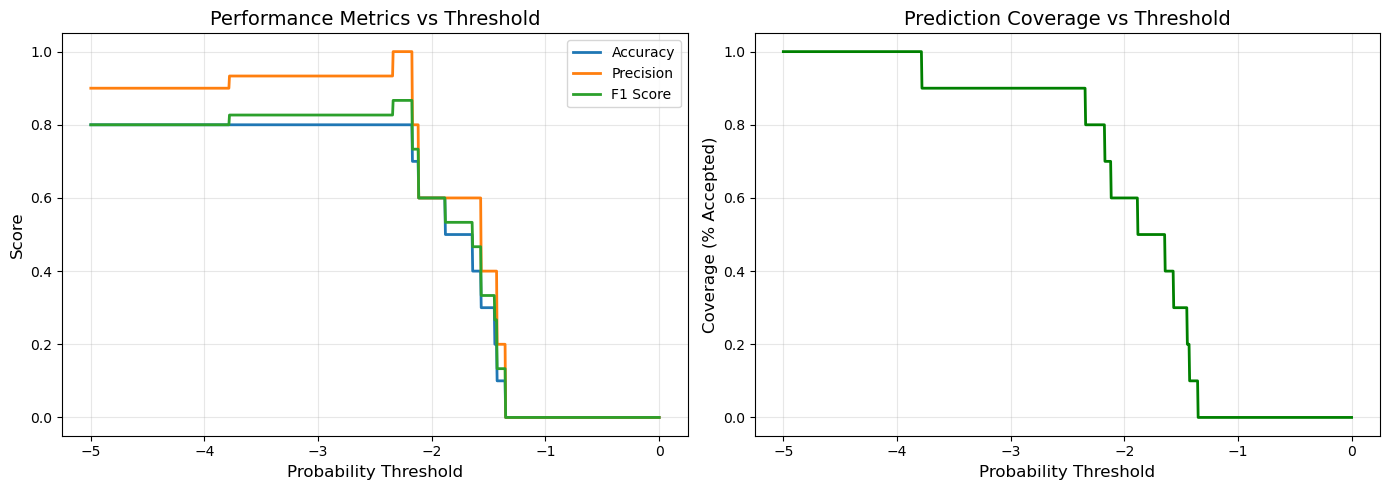

In [20]:
import matplotlib.pyplot as plt

def plot_threshold_analysis(results):
    """
    Visualize how metrics change with threshold.
    """
    thresholds = [r['threshold'] for r in results]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Performance metrics
    ax1.plot(thresholds, [r['accuracy'] for r in results], label='Accuracy', linewidth=2)
    ax1.plot(thresholds, [r['precision'] for r in results], label='Precision', linewidth=2)
    # ax1.plot(thresholds, [r['recall'] for r in results], label='Recall', linewidth=2)
    ax1.plot(thresholds, [r['f1'] for r in results], label='F1 Score', linewidth=2)
    ax1.set_xlabel('Probability Threshold', fontsize=12)
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_title('Performance Metrics vs Threshold', fontsize=14)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Coverage
    ax2.plot(thresholds, [r['coverage'] for r in results], color='green', linewidth=2)
    ax2.set_xlabel('Probability Threshold', fontsize=12)
    ax2.set_ylabel('Coverage (% Accepted)', fontsize=12)
    ax2.set_title('Prediction Coverage vs Threshold', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"../data/imgs/{LANGUAGE}-{RESOURCE}-res-ours-{method}-thresholding-metric-{metric}-grid-{grid}-model-{model}.png", dpi=300, bbox_inches='tight')
    plt.show()

plot_threshold_analysis(result)

In [ ]:
f1_values = np.array([r["f1"] for r in result])
thresholds = np.array([r["threshold"] for r in result])
coverage_values = np.array([r["coverage"] for r in result])

max_f1 = np.max(f1_values)

idxs = np.where(np.isclose(f1_values, max_f1))[0]

if len(idxs) > 0:
    start_idx = idxs[0]
    end_idx = idxs[-1]

    start_threshold = thresholds[start_idx]
    end_threshold = thresholds[end_idx]

    max_coverage = np.max(coverage_values[idxs])

    print(f"Max F1 value: {max_f1}")
    print(f"Interval where F1 is maximum: [{start_threshold}, {end_threshold}]")
    print(f"Max coverage in that interval: {max_coverage}")
else:
    print("No maximum F1 found")

Max F1 value: 0.8666666666666666
Interval where F1 is maximum: [-2.34, -2.175]
Max coverage in that interval: 0.8
